# Part 3: µP Scaling & Extrapolation

1. Implements µP (Maximal Update Parameterization)
2. Runs LR sweep on µP Tiny model
3. Trains all µP model sizes
4. Compares Standard vs µP scaling curves
5. Extrapolates to predict loss for 10× larger model

## 3.1 Setup

In [5]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, yaml, json
BASE_DIR = "/content/drive/MyDrive/svg-scaling"
PROJECT_DIR = "/content/drive/MyDrive/svg-scaling-laws"
sys.path.insert(0, PROJECT_DIR)

!pip install -q datasets tokenizers lxml cairosvg mup wandb scipy seaborn tqdm pyyaml

with open(os.path.join(PROJECT_DIR, "configs", "model_configs.yaml")) as f:
    model_configs = yaml.safe_load(f)
with open(os.path.join(PROJECT_DIR, "configs", "training_config.yaml")) as f:
    train_config = yaml.safe_load(f)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3.2 µP Learning Rate Sweep

In [ ]:
from training.lr_sweep_mup import lr_sweep_mup

best_mup_lr, mup_sweep = lr_sweep_mup(
    model_config=model_configs["tiny"],
    base_config=model_configs["tiny"],
    train_config=train_config,
    model_name="tiny",
    use_wandb=False,
)
print(f"\n Best µP learning rate: {best_mup_lr}")


µP Learning Rate Sweep: tiny
Testing 7 learning rates

--- µP LR = 3.0e-05 ---
  Micro batch size: 64, Gradient accumulation: 1
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~1,881 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~19 batches

Initializing µP model: tiny_lr3e-05

Model: tiny_lr3e-05 (µP)
Total parameters:            1,967,232
Trainable parameters:        1,967,232
Non-embedding parameters:    1,311,872


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Training tiny_lr3e-05 (µP) | LR=3.0e-05 | 1881 iters


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  iter      0/1881 | loss 8.3139 | lr 1.50e-07 | 3128 tok/s | 21s


/content/drive/MyDrive/svg-scaling-laws/training/train.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  >>> val_loss: 8.3141
  iter     50/1881 | loss 8.0371 | lr 7.65e-06 | 678486 tok/s | 50s
  iter    100/1881 | loss 7.6211 | lr 1.52e-05 | 680012 tok/s | 57s
  iter    150/1881 | loss 7.2302 | lr 2.27e-05 | 685100 tok/s | 61s
  iter    200/1881 | loss 6.8990 | lr 3.00e-05 | 695948 tok/s | 66s
  >>> val_loss: 6.8769
  iter    250/1881 | loss 6.5968 | lr 2.99e-05 | 690926 tok/s | 73s
  iter    300/1881 | loss 6.3133 | lr 2.98e-05 | 696825 tok/s | 78s
  iter    350/1881 | loss 6.0541 | lr 2.95e-05 | 697538 tok/s | 83s
  iter    400/1881 | loss 5.7675 | lr 2.91e-05 | 696242 tok/s | 87s
  >>> val_loss: 5.7830
  iter    450/1881 | loss 5.5318 | lr 2.86e-05 | 695541 tok/s | 94s
  iter    500/1881 | loss 5.2912 | lr 2.79e-05 | 697769 tok/s | 99s
  iter    550/1881 | loss 5.0767 | lr 2.72e-05 | 697591 tok/s | 103s
  iter    600/1881 | loss 4.8744 | lr 2.64e-05 | 695246 tok/s | 108s
  >>> val_loss: 4.8738
  iter    650/1881 | loss 4.6587 | lr 2.55e-05 | 697568 tok/s | 115s
  iter    700/1881 | 

## 3.3 Train All µP Models

In [ ]:
# Update config with best µP LR
train_config["learning_rate"] = 0.003

from training.train_mup import train_mup_model

mup_results = {}
for name in ["tiny", "small", "medium"]:
    print(f"\n{'#' * 60}")
    print(f"# Training µP: {name.upper()}")
    print(f"{'#' * 60}")

    current_model_cfg = model_configs[name]

    # dynamic base config matching target depth but Tiny width
    dynamic_base_cfg = current_model_cfg.copy()
    dynamic_base_cfg["n_embd"] = 128  # Tiny width
    dynamic_base_cfg["d_ff"] = 512    # Tiny d_ff
    dynamic_base_cfg["n_head"] = 4    # Tiny head count

    # 2. Passing to function
    results = train_mup_model(
        model_name=name,
        model_config=current_model_cfg,
        base_config=dynamic_base_cfg,
        train_config=train_config,
        use_wandb=False,
    )
    mup_results[name] = results



############################################################
# Training µP: TINY
############################################################
  Micro batch size: 64, Gradient accumulation: 1
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~1,881 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~19 batches

Initializing µP model: tiny

Model: tiny (µP)
Total parameters:            1,967,232
Trainable parameters:        1,967,232
Non-embedding parameters:    1,311,872


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Training tiny (µP) | LR=3.0e-03 | 1881 iters


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  iter      0/1881 | loss 8.3469 | lr 1.50e-05 | 3707 tok/s | 18s


/content/drive/MyDrive/svg-scaling-laws/training/train.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  >>> val_loss: 8.3211
  iter     50/1881 | loss 4.4407 | lr 7.65e-04 | 668208 tok/s | 51s
  iter    100/1881 | loss 2.4879 | lr 1.51e-03 | 686448 tok/s | 57s
  iter    150/1881 | loss 2.3738 | lr 2.27e-03 | 693317 tok/s | 61s
  iter    200/1881 | loss 2.0797 | lr 3.00e-03 | 696156 tok/s | 66s
  >>> val_loss: 2.1854
  iter    250/1881 | loss 1.9505 | lr 2.99e-03 | 694619 tok/s | 73s
  iter    300/1881 | loss 1.8694 | lr 2.98e-03 | 696264 tok/s | 77s
  iter    350/1881 | loss 1.7093 | lr 2.95e-03 | 696947 tok/s | 82s
  iter    400/1881 | loss 1.6824 | lr 2.91e-03 | 698981 tok/s | 87s
  >>> val_loss: 1.6390
  iter    450/1881 | loss 1.6831 | lr 2.86e-03 | 697097 tok/s | 93s
  iter    500/1881 | loss 1.5415 | lr 2.79e-03 | 697002 tok/s | 98s
  iter    550/1881 | loss 1.4181 | lr 2.72e-03 | 696357 tok/s | 103s
  iter    600/1881 | loss 1.4594 | lr 2.64e-03 | 697136 tok/s | 108s
  >>> val_loss: 1.4225
  iter    650/1881 | loss 1.4013 | lr 2.55e-03 | 697948 tok/s | 114s
  iter    700/1881 | 

In [ ]:
train_config["learning_rate"] = 0.003

from training.train_mup import train_mup_model

mup_results = {}
for name in ["large", "xl"]:
    print(f"\n{'#' * 60}")
    print(f"# Training µP: {name.upper()}")
    print(f"{'#' * 60}")

    current_model_cfg = model_configs[name]

    # 1. Create dynamic base config matching target depth but Tiny width
    dynamic_base_cfg = current_model_cfg.copy()
    dynamic_base_cfg["n_embd"] = 128  # Tiny width
    dynamic_base_cfg["d_ff"] = 512    # Tiny d_ff
    dynamic_base_cfg["n_head"] = 4    # Tiny head count

    # 2. Pass IT to the function
    results = train_mup_model(
        model_name=name,
        model_config=current_model_cfg,
        base_config=dynamic_base_cfg,
        train_config=train_config,
        use_wandb=False,
    )


############################################################
# Training µP: LARGE
############################################################
  Micro batch size: 32, Gradient accumulation: 2
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~3,763 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~39 batches

Initializing µP model: large

Model: large (µP)
Total parameters:           36,186,624
Trainable parameters:       36,186,624
Non-embedding parameters:   33,565,184


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Training large (µP) | LR=3.0e-03 | 1881 iters


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  iter      0/1881 | loss 8.3402 | lr 1.50e-05 | 7874 tok/s | 8s


...

  iter      0/1881 | loss 8.3251 | lr 1.50e-05 | 71449 tok/s | 1s
  >>> val_loss: 8.1478
  iter     50/1881 | loss 3.2738 | lr 7.65e-04 | 72387 tok/s | 70s
  iter    100/1881 | loss 2.3127 | lr 1.51e-03 | 72444 tok/s | 116s
  iter    150/1881 | loss 2.2931 | lr 2.27e-03 | 72415 tok/s | 161s
  iter    200/1881 | loss 2.0110 | lr 3.00e-03 | 72457 tok/s | 206s
  >>> val_loss: 1.9960
  iter    250/1881 | loss 1.9052 | lr 2.99e-03 | 72553 tok/s | 264s
  iter    300/1881 | loss 1.6378 | lr 2.98e-03 | 72575 tok/s | 309s


/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):
/content/drive/MyDrive/svg-scaling-laws/training/train_mup.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  iter    350/1881 | loss 1.5113 | lr 2.95e-03 | 72563 tok/s | 354s
  iter    400/1881 | loss 1.3498 | lr 2.91e-03 | 72574 tok/s | 399s


/content/drive/MyDrive/svg-scaling-laws/training/train.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  >>> val_loss: 1.4256
  iter    450/1881 | loss 1.4157 | lr 2.86e-03 | 72552 tok/s | 449s
  iter    500/1881 | loss 1.5603 | lr 2.79e-03 | 72521 tok/s | 495s
  iter    550/1881 | loss 1.2864 | lr 2.72e-03 | 72536 tok/s | 540s
  iter    600/1881 | loss 1.2949 | lr 2.64e-03 | 72575 tok/s | 585s
  >>> val_loss: 1.2512
  iter    650/1881 | loss 1.2141 | lr 2.55e-03 | 72548 tok/s | 635s
  iter    700/1881 | loss 1.2016 | lr 2.45e-03 | 72576 tok/s | 680s
  iter    750/1881 | loss 1.1396 | lr 2.35e-03 | 72562 tok/s | 725s
  iter    800/1881 | loss 1.0687 | lr 2.24e-03 | 72560 tok/s | 771s
  >>> val_loss: 1.1095
  iter    850/1881 | loss 1.0948 | lr 2.12e-03 | 72478 tok/s | 821s
  iter    900/1881 | loss 1.0506 | lr 2.00e-03 | 72584 tok/s | 866s
  iter    950/1881 | loss 1.0062 | lr 1.88e-03 | 72567 tok/s | 911s
  iter   1000/1881 | loss 1.0404 | lr 1.75e-03 | 72569 tok/s | 956s
  >>> val_loss: 1.0114
  iter   1050/1881 | loss 1.0283 | lr 1.63e-03 | 72569 tok/s | 1006s
  iter   1100/1881 | lo

## 3.4 Compare SP vs µP

In [ ]:
import json, os
train_config["learning_rate"] = 0.01
# learning rate string
lr_str = f"{train_config['learning_rate']:.0e}".replace("+", "").replace("0", "")
if lr_str.endswith('-'): lr_str = lr_str[:-1]

#  path
summary_name = f"mup_scaling_summary_lr{lr_str}.json"
summary_path = os.path.join(train_config['results_dir'], summary_name)

# 3. summary dictionary from mup_results variable
summary = {
    name: {
        'params': r['params_non_embedding'],
        'final_val_loss': r['final_val_loss'],
        'best_val_loss': r['best_val_loss'],
        'total_time_s': r['total_time_seconds'],
    } for name, r in mup_results.items()
}

# 4. Save it!
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Successfully saved summary to: {summary_name}")


Successfully saved summary to: mup_scaling_summary_lr3e-3.json


In [ ]:
import os, json

results_dir = train_config['results_dir']
target_lr = "1e-2"
master_summary = {}

for name in ["tiny", "small", "medium", "large", "xl"]:
    target_file = os.path.join(results_dir, f"mup_{name}_lr{target_lr}_results.json")

    # Fallback to the old filename for your early runs
    if not os.path.exists(target_file):
        target_file = os.path.join(results_dir, f"mup_{name}_results.json")

    if os.path.exists(target_file):
        with open(target_file, 'r') as f:
            data = json.load(f)
        master_summary[name] = {
            'params': data['params_non_embedding'],
            'final_val_loss': data['final_val_loss'],
            'best_val_loss': data['best_val_loss'],
            'total_time_s': data['total_time_seconds'],
        }
    else:
        print(f"ERROR: Could not find {name} results!")

with open(os.path.join(results_dir, f"mup_scaling_summary_lr{target_lr}.json"), 'w') as f:
    json.dump(master_summary, f, indent=2)

print(f"Created clean summary for {target_lr} with models: {list(master_summary.keys())}")


Created clean summary for 3e-3 with models: ['tiny', 'small', 'medium', 'large', 'xl']


In [ ]:
from analysis.compare_sp_mup import compare_sp_vs_mup, plot_lr_sweep_comparison

RESULTS_DIR = train_config["results_dir"]
ANALYSIS_DIR = os.path.join(BASE_DIR, "results", "analysis")

comparison = compare_sp_vs_mup(RESULTS_DIR, ANALYSIS_DIR, mup_lr="1e-2")
plot_lr_sweep_comparison(RESULTS_DIR, ANALYSIS_DIR)

Saved comparison plot to sp_vs_mup_scaling_lr1e-2.png

SP vs µP Comparison
Model         SP Loss    µP Loss          Δ    Improve
--------------------------------------------------
tiny           1.1600     1.0050    +0.1550     +13.4%
small          0.9988     0.9145    +0.0843      +8.4%
medium         0.8560     0.8511    +0.0049      +0.6%
large          0.7663     0.7853    -0.0190      -2.5%
xl             0.6799     0.7548    -0.0749     -11.0%

Scaling exponent (α):
  SP:  0.2206
  µP:  0.2360
  Improvement: +6.9%
Saved LR sweep comparison plot


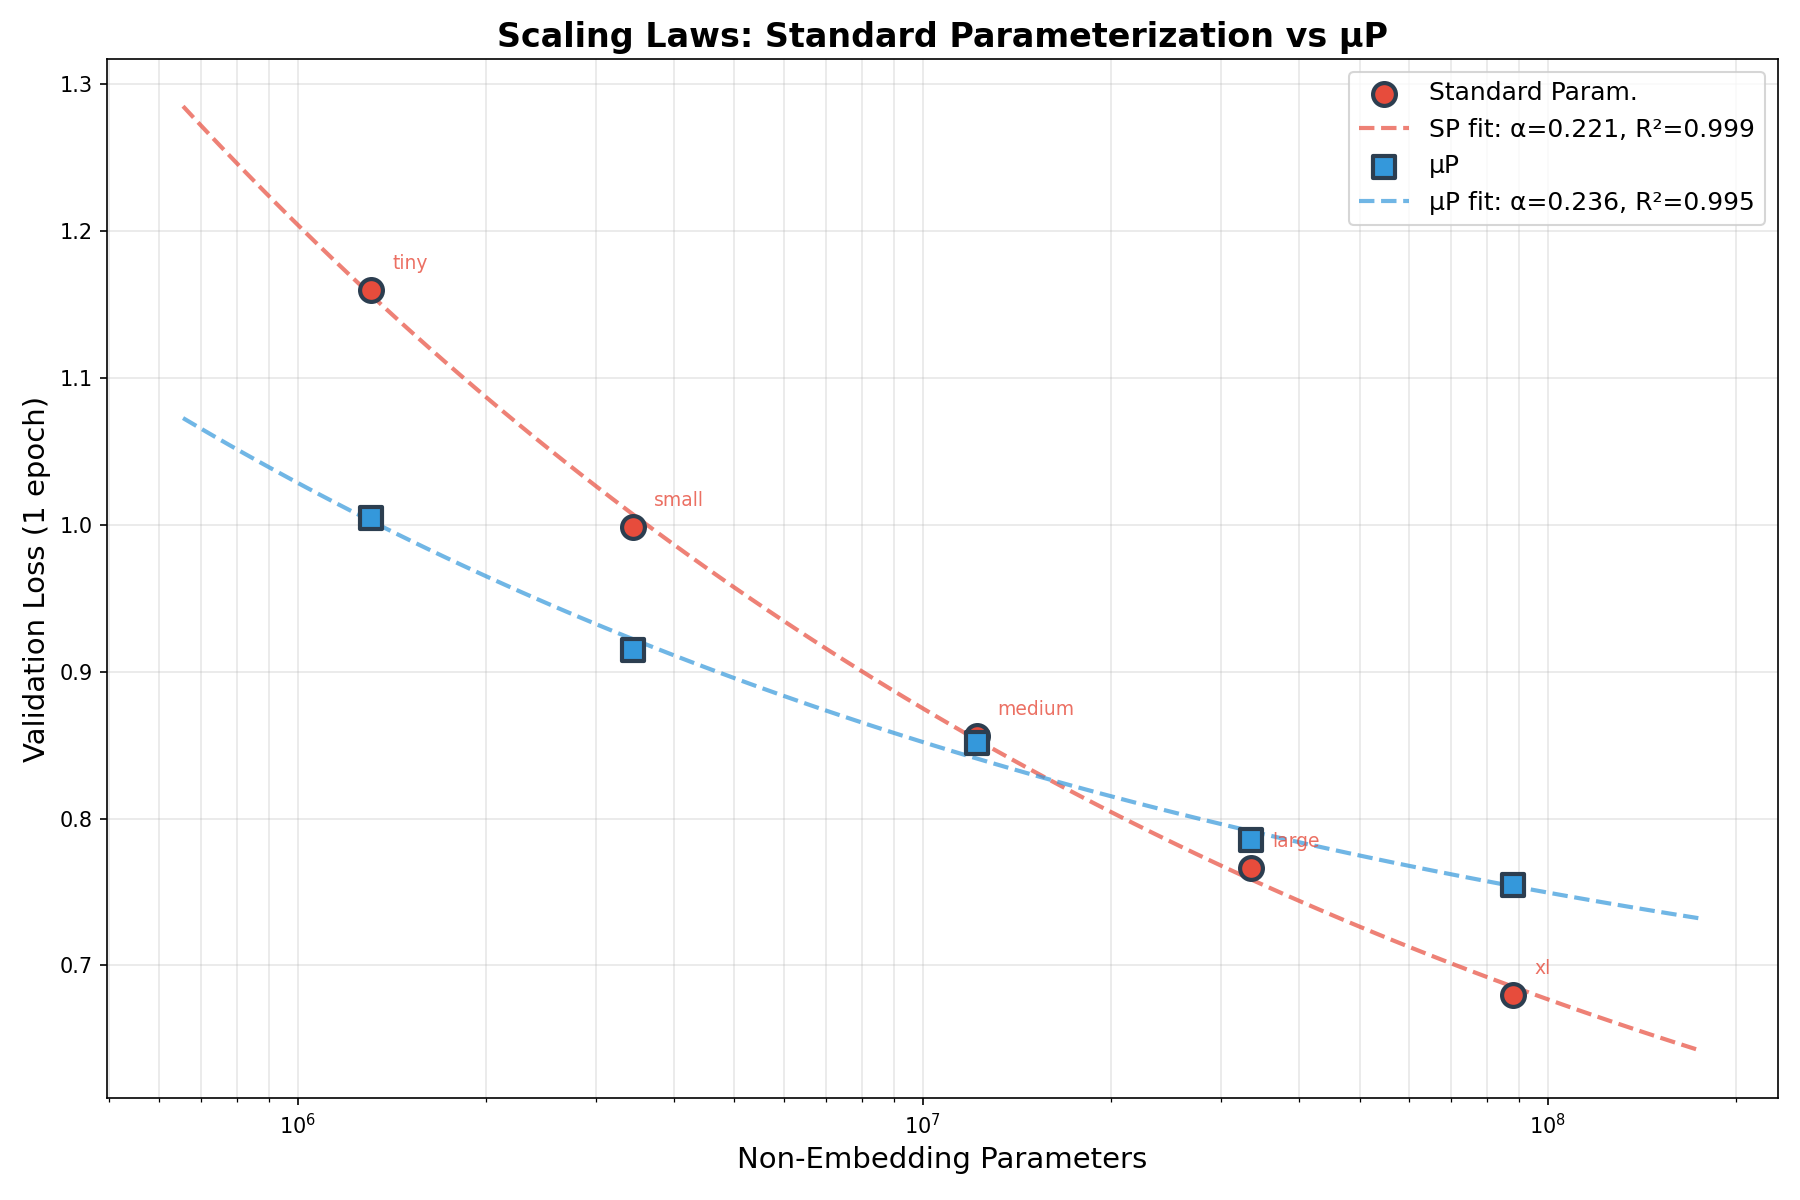

In [ ]:
from IPython.display import Image, display
import os

# Ensure lr_str is defined for consistent naming
train_config["learning_rate"]=0.01
lr = train_config["learning_rate"]
lr_str = f"{lr:.0e}".replace("+", "").replace("0", "")

# Construct the filenames using the lr_str for sp_vs_mup_scaling.png
# and the original name for lr_sweep_comparison.png
images_to_display = [
    f"sp_vs_mup_scaling_lr{lr_str}.png",
]

for img in images_to_display:
    path = os.path.join(ANALYSIS_DIR, img)
    if os.path.exists(path):
        display(Image(path, width=700))
    else:
        print(f"Warning: Image '{img}' not found at '{path}'")

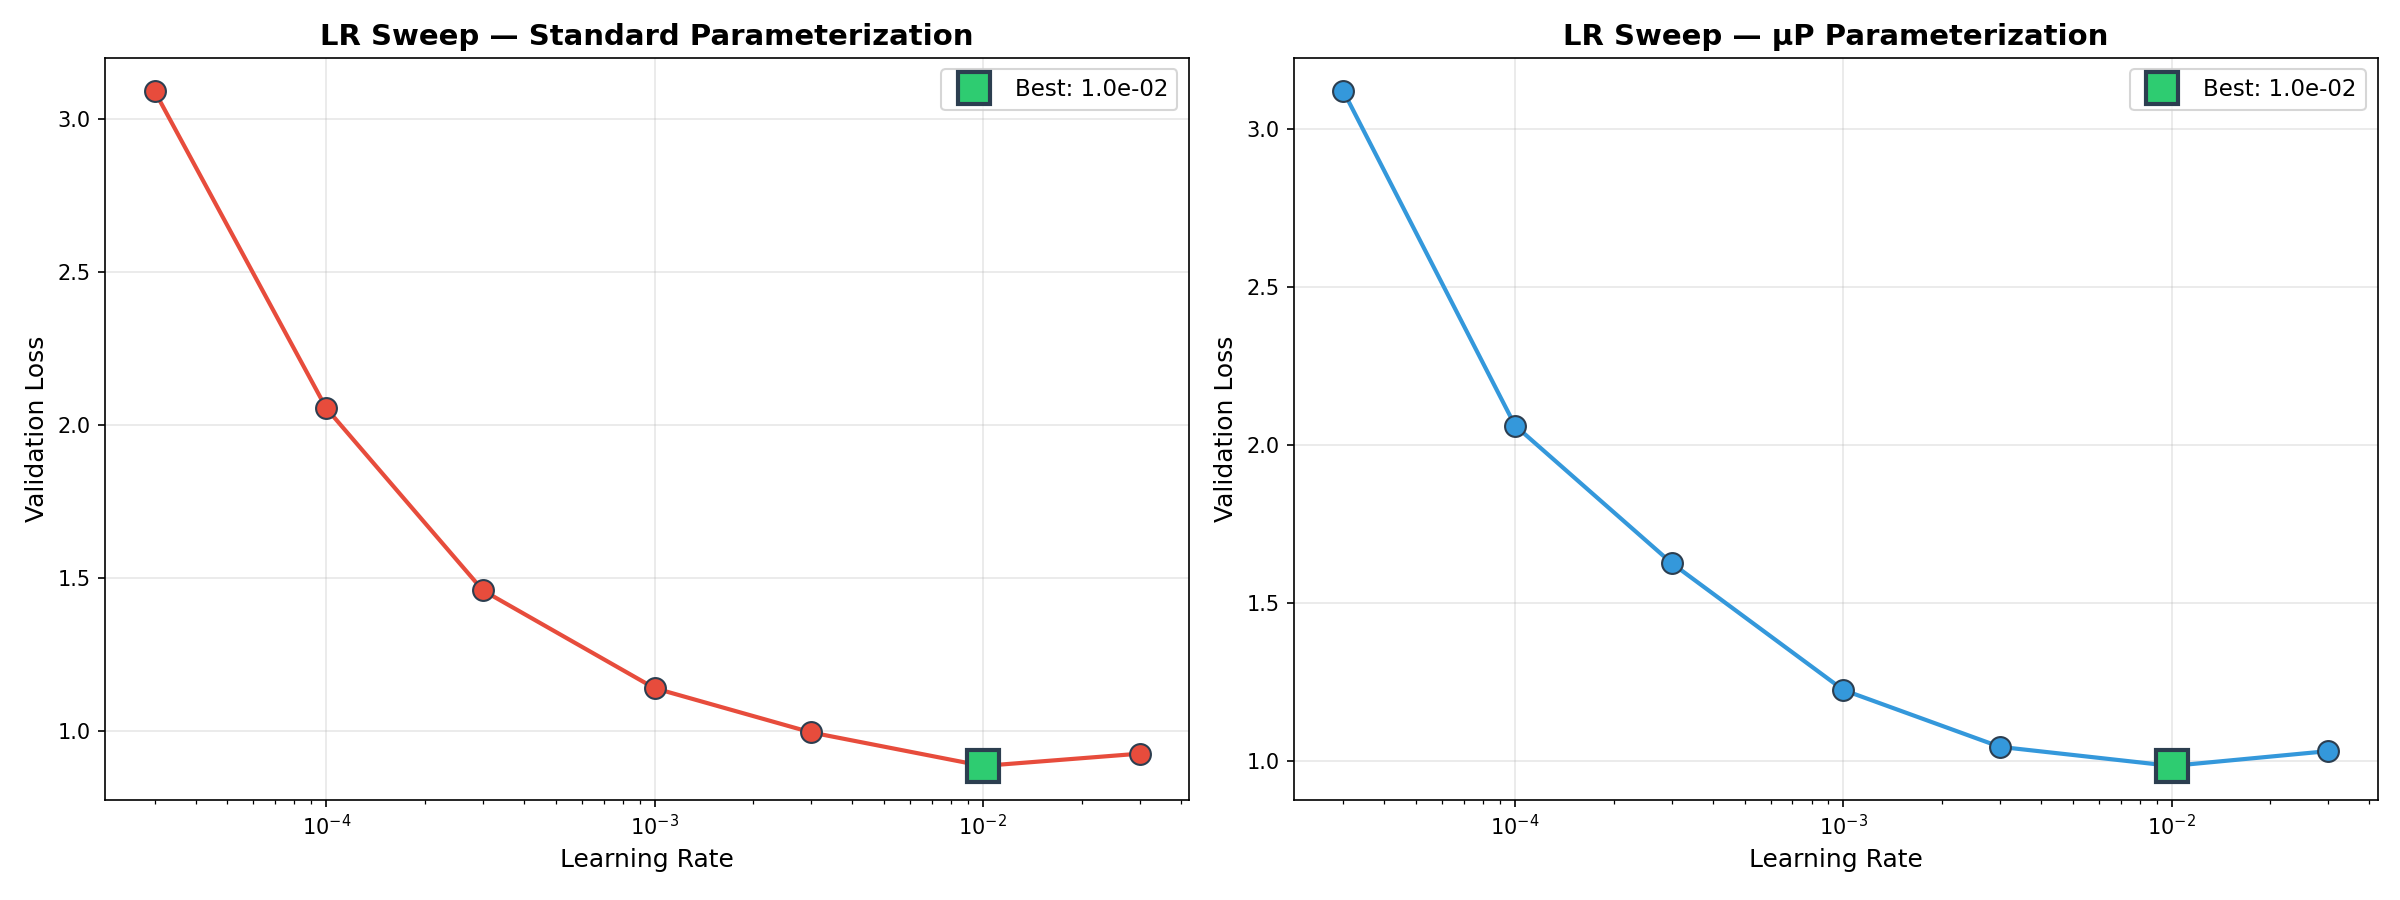

In [7]:
from IPython.display import Image, display
for img in ["sp_vs_mup_scaling.png", "lr_sweep_comparison.png"]:
    path = os.path.join(ANALYSIS_DIR, img)
    if os.path.exists(path):
        display(Image(path, width=700))

## 3.5 Scaling Law Extrapolation

In [28]:
import importlib
from analysis import extrapolation
importlib.reload(extrapolation)
from analysis.extrapolation import extrapolate_scaling_law
extrapolation = extrapolate_scaling_law(
    results_dir=RESULTS_DIR,
    output_dir=ANALYSIS_DIR,
    extrapolation_factor=10,
    mup_lr="1e-2"  # future of best model
)



Using µP (LR=1e-2) scaling law: L = 10.9713 · N^(-0.2360) + 0.6075
R² = 0.9950

Extrapolation Results:
  Largest trained model: 88,099,584 params → loss = 0.7548
  Extrapolation target:  880,995,840 params (10×)
  Predicted loss:        0.6925
  95% CI:                [0.6402, 0.7449]
  Uncertainty (σ):       0.0267
Saved extrapolation plot


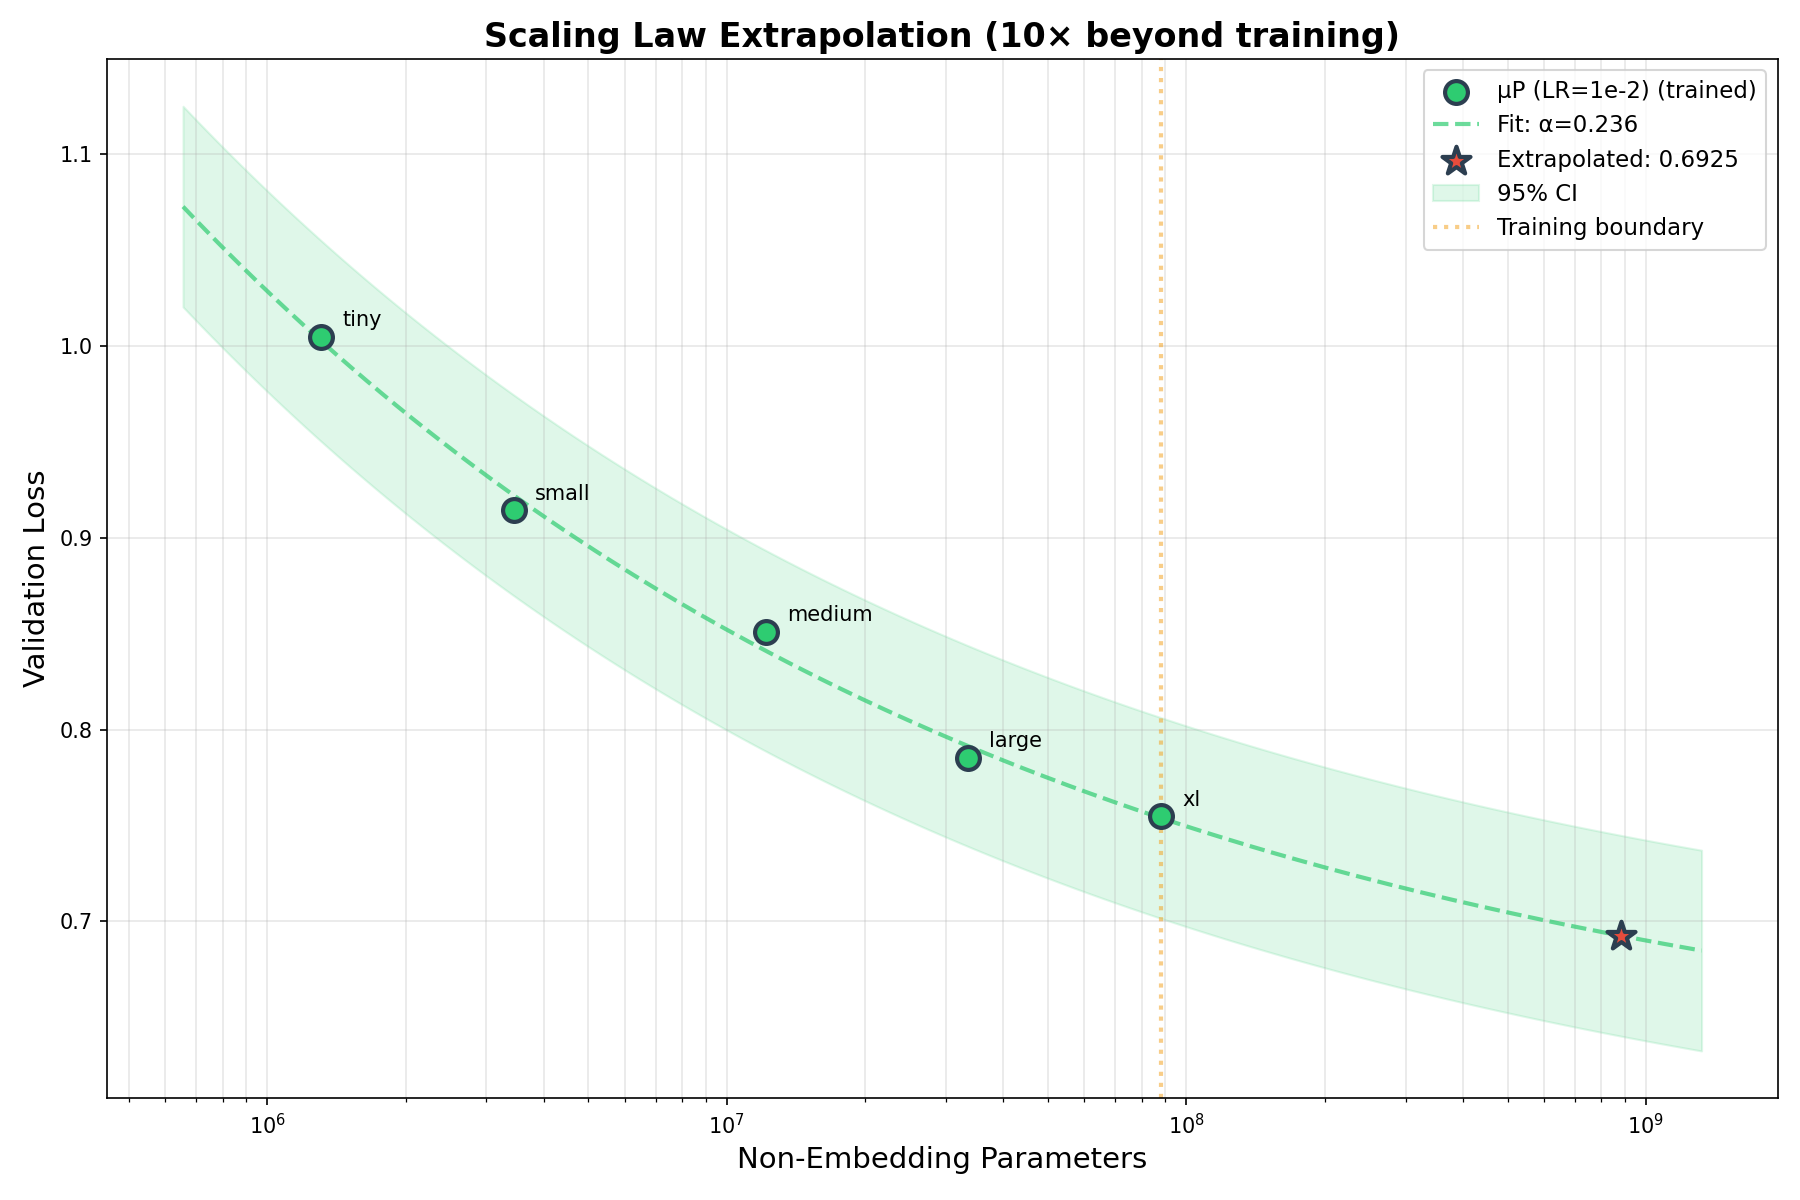

In [13]:
path = os.path.join(ANALYSIS_DIR, "scaling_extrapolation.png")
if os.path.exists(path):
    display(Image(path, width=700))